In [1]:
import os, pickle, math, warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# ---------- Configuración ----------
alpha = 0.05
lam = 1.0
rng = np.random.default_rng(42)


In [5]:
with open("./bits_mersenne_twister.pkl", "rb") as f:
    arr = pickle.load(f)

# Convertir bits (0 o 1) a floats en [0,1)
bits = np.array(arr, dtype=np.uint8)
N = len(bits) // 32
if bits.size < N * 32:
    raise ValueError("No hay suficientes bits para generar la muestra.")

bits = bits[:N * 32].reshape(-1, 32)
weights = (2 ** np.arange(32)).astype(np.uint64)
vals = (bits * weights).sum(axis=1).astype(np.uint64)
loaded_U = (vals / 2**32).astype(float)

In [6]:
N = loaded_U.size
# Transformada integral a Exponencial
empirical = -np.log1p(-loaded_U) / lam
theoretical = stats.expon.rvs(scale=1/lam, size=N, random_state=42)


### Estadisticos descriptivos

In [7]:
def describe(x):
    return {
        "n": x.size,
        "media": float(np.mean(x)),
        "desv_est": float(np.std(x, ddof=1)),
        "min": float(np.min(x)),
        "q1": float(np.quantile(x, 0.25)),
        "mediana": float(np.median(x)),
        "q3": float(np.quantile(x, 0.75)),
        "max": float(np.max(x)),
    }

desc_theo = describe(theoretical)
desc_emp = describe(empirical)

print("\nEstadísticos descriptivos (Exponencial λ=%.3f)" % lam)
for k in desc_theo.keys():
    print(f"  {k:>9}: teórica={desc_theo[k]: .5f} | empírica={desc_emp[k]: .5f}")



Estadísticos descriptivos (Exponencial λ=1.000)
          n: teórica= 31250.00000 | empírica= 31250.00000
      media: teórica= 0.99825 | empírica= 1.00852
   desv_est: teórica= 0.99724 | empírica= 1.01180
        min: teórica= 0.00001 | empírica= 0.00002
         q1: teórica= 0.28919 | empírica= 0.28977
    mediana: teórica= 0.69407 | empírica= 0.69593
         q3: teórica= 1.38137 | empírica= 1.40048
        max: teórica= 9.49572 | empírica= 9.91021


### Graficos

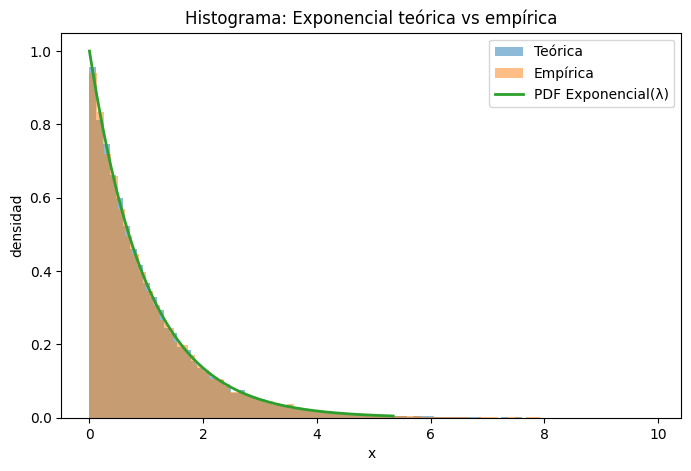

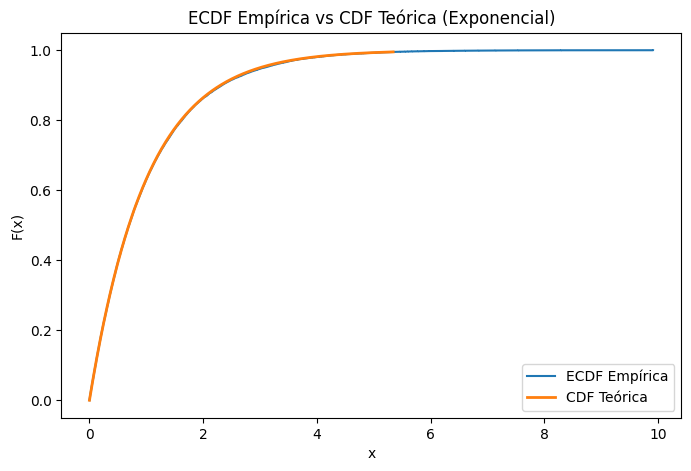

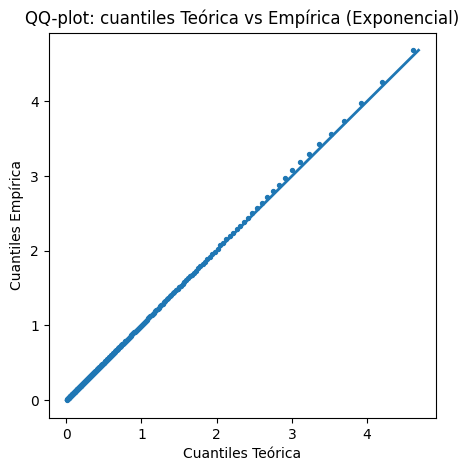

In [8]:
# Histograma + PDF teórica
plt.figure(figsize=(8,5))
plt.hist(theoretical, bins=80, density=True, alpha=0.5, label="Teórica")
plt.hist(empirical,   bins=80, density=True, alpha=0.5, label="Empírica")
x = np.linspace(0, np.quantile(np.concatenate([theoretical, empirical]), 0.995), 600)
plt.plot(x, lam*np.exp(-lam*x), linewidth=2, label="PDF Exponencial(λ)")
plt.title("Histograma: Exponencial teórica vs empírica")
plt.xlabel("x"); plt.ylabel("densidad"); plt.legend(); plt.show()

# ECDF vs CDF teórica
def ecdf(y):
    y = np.sort(y)
    n = y.size
    return y, np.arange(1, n+1)/n

x_emp, F_emp = ecdf(empirical)
x_the, F_the = ecdf(theoretical)
plt.figure(figsize=(8,5))
plt.step(x_emp, F_emp, where="post", label="ECDF Empírica")
plt.plot(x, 1-np.exp(-lam*x), linewidth=2, label="CDF Teórica")
plt.title("ECDF Empírica vs CDF Teórica (Exponencial)")
plt.xlabel("x"); plt.ylabel("F(x)"); plt.legend(); plt.show()

# QQ-plot
q = np.linspace(0.01, 0.99, 199)
q_theo = stats.expon.ppf(q, scale=1/lam)
q_emp  = np.quantile(empirical, q)
plt.figure(figsize=(5,5))
plt.scatter(q_theo, q_emp, s=8)
lims = [0, max(q_theo.max(), q_emp.max())]
plt.plot(lims, lims, linewidth=2)
plt.title("QQ-plot: cuantiles Teórica vs Empírica (Exponencial)")
plt.xlabel("Cuantiles Teórica"); plt.ylabel("Cuantiles Empírica"); plt.show()
